In [1]:
import numpy as np
from scipy.constants import h, c, k
from scipy.integrate import quad
from scipy.interpolate import interp1d
import pandas as pd 
import matplotlib.pyplot as plt
from pathlib import Path
import os
import datetime
import csv
from datetime import datetime

In [3]:
# === SETTINGS ===
ID = "A2"  # Station ID

# === File Paths ===
dir_path = Path.cwd()  # current working directory
print("Current working directory:", dir_path)

# Data directory 
data_dir = dir_path.parent / "data"
# Protocols directory 
protocol_dir = dir_path.parent / "protocols"
# Halobates data directory 
halobates_dir =  data_dir / "halobates_data"
# Results directory 
results_dir = dir_path.parent / "results"
# Output path for the raw SST temperature
out_dir = dir_path / "raw"
# Output path for the averaged SST temperature
out_dir_avg = dir_path / "1min"
# Radiances before correction
out_dir_rad = dir_path / "uncorrected_radiances"


# Halobates file
halobates_file = sorted(halobates_dir.glob(f"{ID}_Halobates.csv"))
halobates_file  = str(halobates_file[0])

# Halobates protocol file
protocol_file = sorted(protocol_dir.glob(f"*{ID}_17_CST_Schedule.csv"))
protocol_file  = str(protocol_file[0])


# Output path for SST vs SML data
sst_sml_output_file = results_dir / "SST_vs_SML.csv"

# === Debug output (optional) ===
print("Halobates data file:", halobates_file)
print("Halobates protocol file:", protocol_file)

Current working directory: c:\Users\ludog\Nextcloud\CLEWS\work\METEOR\IR Camera\github\Infrared_cameras\postproc
Halobates data file: c:\Users\ludog\Nextcloud\CLEWS\work\METEOR\IR Camera\github\Infrared_cameras\data\halobates_data\A2_Halobates.csv
Halobates protocol file: c:\Users\ludog\Nextcloud\CLEWS\work\METEOR\IR Camera\github\Infrared_cameras\protocols\20250629_A2_17_CST_Schedule.csv


### Clip SST temperatures based on Halobates protocol

C:\Users\ludog\AppData\Local\Temp\ipykernel_14096\3148983502.py:2: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_halo = pd.read_csv(halobates_file, parse_dates=['Date_Time'])


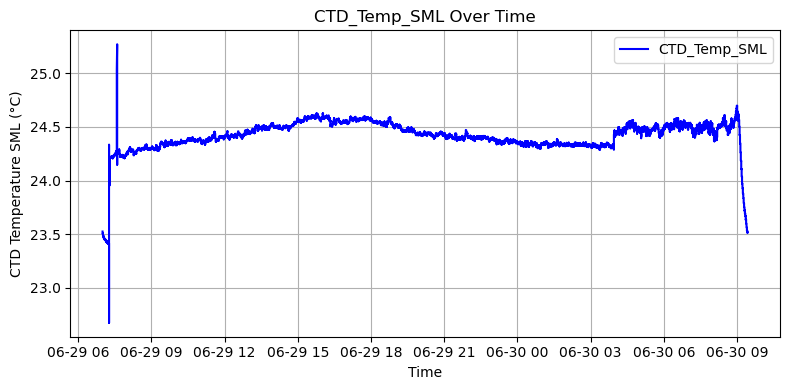

In [6]:
# Load Halobates data
df_halo = pd.read_csv(halobates_file, parse_dates=['Date_Time'])

# Rename time column for consistency    
df_halo  = df_halo.rename(columns={'Date_Time': 'Time'})

# Plot SML temperature 
plt.figure(figsize=(8, 4))
plt.plot(df_halo['Time'], df_halo['CTD_Temp_SML'], label='CTD_Temp_SML', color='blue')
plt.xlabel('Time')
plt.ylabel('CTD Temperature SML (°C)')
plt.title('CTD_Temp_SML Over Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [8]:
# === Load Halobates protocol data ===
df_protocol = pd.read_csv(protocol_file, sep=";", decimal=",")
df_protocol

# Convert 'Date_Time' column to datetime format
for col in df_protocol.columns[1:]:
    df_protocol[col] = pd.to_datetime(df_protocol[col], format="%d.%m.%Y %H:%M:%S", errors='coerce').dt.strftime("%Y-%m-%d %H:%M:%S")


In [ ]:
def find_position_time(subset, time):

    position = np.array(subset.apply(str).str.find(time))
    return np.where(position == 0)[0][0]


def clip_time_data(df, start, end):

    df_set = df.copy()

    # === Clip the SST data to the period halobates was on water ===
    start_time = pd.to_datetime(start)
    end_time = pd.to_datetime(end)
    subset = df_set[(df_set["Time"] >= start_time) & (df_set["Time"] <= end_time)]

    return subset

def cut_time_data(df, start, end, sst_variable):

    df_set = df.copy()

    # === Cut the SST data when there were intervetions ===
    start_time = pd.to_datetime(start)
    end_time = pd.to_datetime(end)
    df_set.loc[(df_set["Time"] >= start_time) & (df_set["Time"] <= end_time), sst_variable] = np.nan

    return df_set

def update_time(time_str, seconds_shift):

    time = pd.to_datetime(time_str)
    actual_minute = time.minute
    actual_second = time.second

    shift_minute = pd.to_datetime(str(datetime.timedelta(seconds=seconds_shift))).minute
    shift_second = pd.to_datetime(str(datetime.timedelta(seconds=seconds_shift))).second

    new_time = time.replace(minute = actual_minute - shift_minute, second = actual_second - shift_second) 

    return new_time

def find_start_time(df, start_time, sst_variable, seconds_shift):

    df_set = df.copy()
    num_std = 2

    reference_time = pd.to_datetime(start_time) + datetime.timedelta(minutes = - seconds_shift)
    reference_set = df_set[(df_set["Time"] >= reference_time) & (df_set["Time"] <= start_time)]

    mean_clean = pd.DataFrame(reference_set[sst_variable]).describe().loc['mean']
    std_clean = pd.DataFrame(reference_set[sst_variable]).describe().loc['std']

    threshold_SST = mean_clean + num_std *std_clean
    start_position = find_position_time(df_set["Time"], start_time) + 1
    local_SST = df_set[sst_variable][start_position]

    counter = 0

    while local_SST < threshold_SST[sst_variable]:
        
        local_SST = df_set[sst_variable][start_position + counter]
        counter = counter + 1 

        if counter == 60*60:

            print('No interferences detected')
            return pd.to_datetime(0)

    return df_set["Time"][start_position + counter]

def find_end_time(df, start_time, sst_variable, seconds_shift):

    df_set = df.copy()
    num_std = 2

    reference_time = pd.to_datetime(start_time) + datetime.timedelta(minutes = - seconds_shift)
    reference_set = df_set[(df_set["Time"] >= reference_time) & (df_set["Time"] <= start_time)]

    mean_clean = pd.DataFrame(reference_set[sst_variable]).describe().loc['mean']
    std_clean = pd.DataFrame(reference_set[sst_variable]).describe().loc['std']

    threshold_SST = mean_clean + num_std *std_clean
    start_position = find_position_time(df_set["Time"], start_time) + 1
    local_SST = df_set[sst_variable][start_position]

    last_counter = 0

    for second in range(60*30):
        
        local_SST = df_set[sst_variable][start_position + second]

        if local_SST > threshold_SST[sst_variable]:

            last_counter = second

        else:

            last_counter = last_counter

    return df_set["Time"][start_position + last_counter]


def clean_time_data(df_sst, df_protocol, sst_variable):

    seconds_shift = 300

    for int in range(len(df_protocol[2:])):

        start_protocol = df_protocol["Start"][2+int]
        start_real = find_start_time(df_sst, start_protocol, sst_variable, seconds_shift)

        if start_real != pd.to_datetime(0):

            end_real = find_end_time(df_sst, str(start_real), sst_variable, seconds_shift)
            df_sst = cut_time_data(df_sst, start_real, end_real, sst_variable)

            print(int, start_protocol, start_real, end_real)

    deployment = df_protocol["Start"][0]
    recover = df_protocol["End"][0]
    df_set = clip_time_data(df_sst, deployment, recover)

    bridge_up = df_protocol["Start"][1]
    bridge_down = df_protocol["End"][1]
    df_set = clip_time_data(df_set, bridge_up , bridge_down)

    return df_set